In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer 

In [ ]:
df=pd.read_csv(r"C:\Users\SHILA\OneDrive\Desktop\PYTHON\ML_practiceDays\Datasets\titanic.csv", usecols=['Age','Fare','Survived'])
df.shape

(891, 3)

In [15]:
df.dropna(inplace=True)
df.shape

(714, 3)

In [16]:
df.sample(4)

,Survived,Age,Fare
252,0,62.0,26.550
68,1,17.0,7.925
365,0,30.0,7.250
297,0,2.0,151.550


In [17]:
x=df.iloc[ : , 1 : ]
y=df.iloc[ : , 0]

In [18]:
xtrain, xtest, ytrain, ytest=train_test_split(x, y, test_size=0.2, random_state=42)

In [19]:
xtrain.head(4)

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542
253,30.0,16.1000
719,33.0,7.7750


In [20]:
clf=DecisionTreeClassifier()
clf.fit(xtrain,ytrain)

DecisionTreeClassifier()

In [21]:
ypred=clf.predict(xtest)
accuracy_score(ytest, ypred)

0.6503496503496503

In [25]:
np.mean(cross_val_score(DecisionTreeClassifier(), x, y, cv=10, scoring='accuracy'))

0.6386932707355242

In [26]:
kbin_age=KBinsDiscretizer(n_bins=15, encode='ordinal', strategy='quantile')
kbin_fare=KBinsDiscretizer(n_bins=15, encode='ordinal', strategy='quantile') 

In [27]:
trf=ColumnTransformer([
    ('first', kbin_age, [0]),
    ('second', kbin_fare, [1])
])

In [28]:
xtrain_trans=trf.fit_transform(xtrain)
xtest_trans=trf.transform(xtest)

In [29]:
trf.named_transformers_['first'].n_bins_

array([15])

In [30]:
trf.named_transformers_['second'].n_bins_

array([15])

In [31]:
trf.named_transformers_

{'first': KBinsDiscretizer(encode='ordinal', n_bins=15),
 'second': KBinsDiscretizer(encode='ordinal', n_bins=15)}

In [32]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42,  6.  , 16.  , 19.  , 21.  , 23.  , 25.  , 28.  , 30.  ,
              32.  , 35.  , 38.  , 42.  , 47.  , 54.  , 80.  ])             ],
      dtype=object)

In [33]:
output=pd.DataFrame({
    'age' : xtrain['Age'],
    'age_trf' : xtrain_trans[ : , 0],
    'fare' : xtrain['Fare'],
    'fare_trf' : xtrain_trans[ : , 1] 
})

In [35]:
output['age_label']=pd.cut(x=xtrain['Age'], bins=trf.named_transformers_['first'].bin_edges_[0].tolist())
output['fare_label']=pd.cut(x=xtrain['Fare'], bins=trf.named_transformers_['second'].bin_edges_[0].tolist())

In [36]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_label,fare_label
800,34.0,9.0,13.00,6.0,"(32.0, 35.0]","(10.5, 13.0]"
323,22.0,4.0,29.00,10.0,"(21.0, 23.0]","(26.55, 31.275]"
360,40.0,11.0,27.90,10.0,"(38.0, 42.0]","(26.55, 31.275]"
595,36.0,10.0,24.15,8.0,"(35.0, 38.0]","(18.75, 26.0]"
632,32.0,9.0,30.50,10.0,"(30.0, 32.0]","(26.55, 31.275]"


In [37]:
clf=DecisionTreeClassifier()
clf.fit(xtrain_trans,ytrain)
ypred2=clf.predict(xtest_trans)

In [38]:
accuracy_score(ytest,ypred2)

0.6363636363636364

In [39]:
xtrf=trf.fit_transform(x)
np.mean(cross_val_score(DecisionTreeClassifier(), x, y, cv=10, scoring='accuracy'))

0.6317097026604068

In [40]:
# function 
def discretizer(bins,strategy):
    kbin_age=KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy=strategy)
    kbin_fare=KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy=strategy)

    trf=ColumnTransformer([
        ('fst', kbin_age, [0]),
        ('scnd', kbin_fare, [1])
    ])

    xtrf=trf.fit_transform(x)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),x,y,cv=10,scoring='accuracy')))

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(x['Age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(x['Age'])
    plt.title("After")

    plt.show()

0.6345070422535211


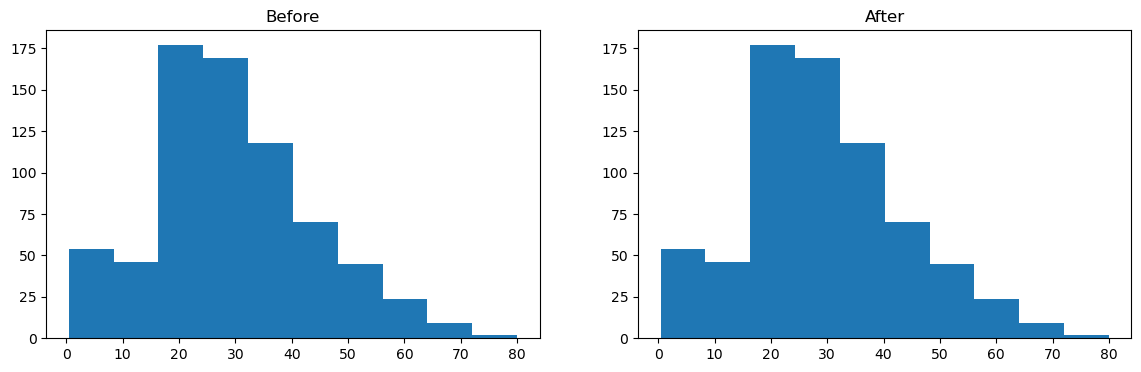

In [41]:
discretizer(10,'quantile')